#  Code-Mixed Language Sentiment Detection using mT5
**Dataset**: Marathi-English Code-Mixed Tweets  
**Labels**: `1 = Positive` | `0 = Neutral` | `-1 = Negative`  
**Model**: `google/mt5-small` fine-tuned for 3-class sentiment classification  

>  **Runtime**: Go to `Runtime → Change runtime type → GPU (T4)` before running!


## CELL 1: Install Dependencies


In [ ]:
"""
!pip install transformers==4.40.0 datasets sentencepiece accelerate -q
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 -q
"""

'\n!pip install transformers==4.40.0 datasets sentencepiece accelerate -q\n!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 -q\n'

## CELL 2: Imports


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    MT5ForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
import warnings
warnings.filterwarnings("ignore")

# Set seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Using device: cuda
GPU: Tesla T4


## CELL 3: Upload & Load Dataset


In [ ]:
from google.colab import files
print("Upload your Excel dataset (.xlsx):")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_excel(filename)
print(f"\nDataset shape: {df.shape}")
print(df.head())
print("\nLabel distribution:")
print(df['label'].value_counts())

Upload your Excel dataset (.xlsx):


Saving Marathi__english_very_less__dataset_for_DM_Proj.xlsx to Marathi__english_very_less__dataset_for_DM_Proj.xlsx

Dataset shape: (1500, 2)
                                               tweet  label
0    कोरोना काळात आपले पंतप्रधान मा. नरेंद्र मोदी...      1
1    पुणे येथे राष्ट्रसेवा दल अभ्यासिका विभाग यां...      1
2    पुणे येथील "क्रांती ज्योती" या कार्यक्रमात ज...      0
3    आद्यक्रांतिकारक उमाजीराजे नाईक यांना जयंतीनि...      1
4    महाराष्ट्राचे मुख्यमंत्री म्हणून शपथ घेतल्या...      1

Label distribution:
label
 1    500
 0    500
-1    500
Name: count, dtype: int64


## CELL 4: Label Mapping (1=Positive, 0=Neutral, -1=Negative)



Label mapping applied:
   label sentiment  label_id
0      1  Positive         0
2      0   Neutral         1
7     -1  Negative         2

Class distribution:
sentiment
Positive    500
Neutral     500
Negative    500
Name: count, dtype: int64


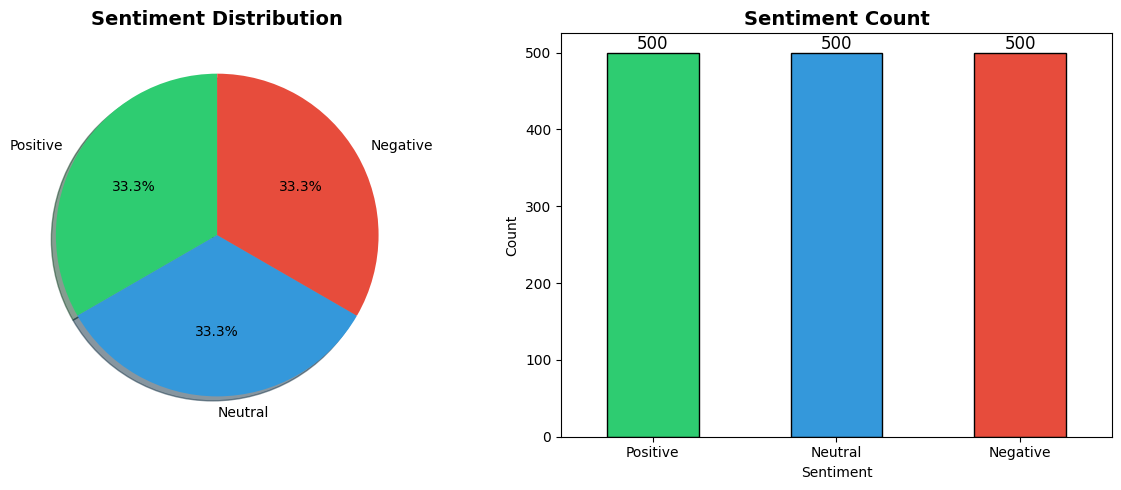

In [ ]:
label2id = {1: 0, 0: 1, -1: 2}   # map to 0-indexed for model
id2label = {0: "Positive", 1: "Neutral", 2: "Negative"}
sentiment_map = {1: "Positive", 0: "Neutral", -1: "Negative"}

df['sentiment'] = df['label'].map(sentiment_map)
df['label_id'] = df['label'].map(label2id)

print("\nLabel mapping applied:")
print(df[['label', 'sentiment', 'label_id']].drop_duplicates().sort_values('label_id'))
print("\nClass distribution:")
print(df['sentiment'].value_counts())

# Distribution pie chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2ecc71', '#3498db', '#e74c3c']
df['sentiment'].value_counts().plot.pie(
    ax=axes[0], autopct='%1.1f%%', colors=colors,
    startangle=90, shadow=True
)
axes[0].set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')

df['sentiment'].value_counts().plot.bar(ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Sentiment Count', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
for bar in axes[1].patches:
    axes[1].annotate(f'{int(bar.get_height())}',
                     (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                     ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## CELL 5: Train/Val/Test Split (70/15/15)


In [ ]:
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED,
                                     stratify=df['label_id'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED,
                                   stratify=temp_df['label_id'])

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print("\nTrain label distribution:")
print(train_df['sentiment'].value_counts())

Train: 1050 | Val: 225 | Test: 225

Train label distribution:
sentiment
Positive    350
Neutral     350
Negative    350
Name: count, dtype: int64


## CELL 6: Tokenizer & Dataset Class


In [ ]:
MODEL_NAME = "google/mt5-small"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 10
LR = 2e-4

print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = SentimentDataset(train_df['tweet'], train_df['label_id'], tokenizer, MAX_LEN)
val_dataset   = SentimentDataset(val_df['tweet'],   val_df['label_id'],   tokenizer, MAX_LEN)
test_dataset  = SentimentDataset(test_df['tweet'],  test_df['label_id'],  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Loading tokenizer: google/mt5-small


config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

Train batches: 66 | Val batches: 15 | Test batches: 15


## CELL 7: Load mT5 Model


In [ ]:
print(f"\nLoading mT5 model for sequence classification...")
model = MT5ForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id={v: k for k, v in id2label.items()}
)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Loading mT5 model for sequence classification...


pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/191 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.shared.weight to transformer.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie transformer.shared.weight to transformer.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
MT5ForSequenceClassification LOAD REPORT from: google/mt5-small
Key                                 | Status     | 
------------------------------------+------------+-
lm_head.weight                      | UNEXPECTED | 
classification_head.out_proj.bias   | MISSING    | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSIN

Total parameters:     428,498,307
Trainable parameters: 428,498,307


## CELL 8: Optimizer, Scheduler & Class Weights


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=train_df['label_id'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class weights: {class_weights}")

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

Class weights: [1. 1. 1.]


## CELL 9: Training & Validation Functions


In [ ]:
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits
        loss    = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits  = outputs.logits
            loss    = criterion(logits, labels)

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels

## CELL 10: Training Loop


In [ ]:
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc': []
}

best_val_loss = float('inf')
best_val_acc  = 0.0
patience = 3
no_improve = 0

print("=" * 60)
print("         TRAINING mT5 FOR SENTIMENT DETECTION")
print("=" * 60)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion, device)
    val_loss,   val_acc, val_preds, val_labels = eval_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch [{epoch:02d}/{EPOCHS}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc  = val_acc
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_mt5_sentiment.pt')
        print(f"  ✅ Best model saved! Val Acc: {best_val_acc:.4f}")
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"\n  ⏹ Early stopping triggered after {epoch} epochs.")
            break

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")

         TRAINING mT5 FOR SENTIMENT DETECTION
Epoch [01/10] | Train Loss: 1.1200 | Train Acc: 0.3524 | Val Loss: 1.0637 | Val Acc: 0.4578
  ✅ Best model saved! Val Acc: 0.4578
Epoch [02/10] | Train Loss: 1.0955 | Train Acc: 0.3686 | Val Loss: 1.0637 | Val Acc: 0.4578
Epoch [03/10] | Train Loss: 1.0868 | Train Acc: 0.3819 | Val Loss: 1.0637 | Val Acc: 0.4578
Epoch [04/10] | Train Loss: 1.1120 | Train Acc: 0.3400 | Val Loss: 1.0637 | Val Acc: 0.4578

  ⏹ Early stopping triggered after 4 epochs.

Best Validation Accuracy: 0.4578


## CELL 11: Training & Validation Loss/Accuracy Graphs


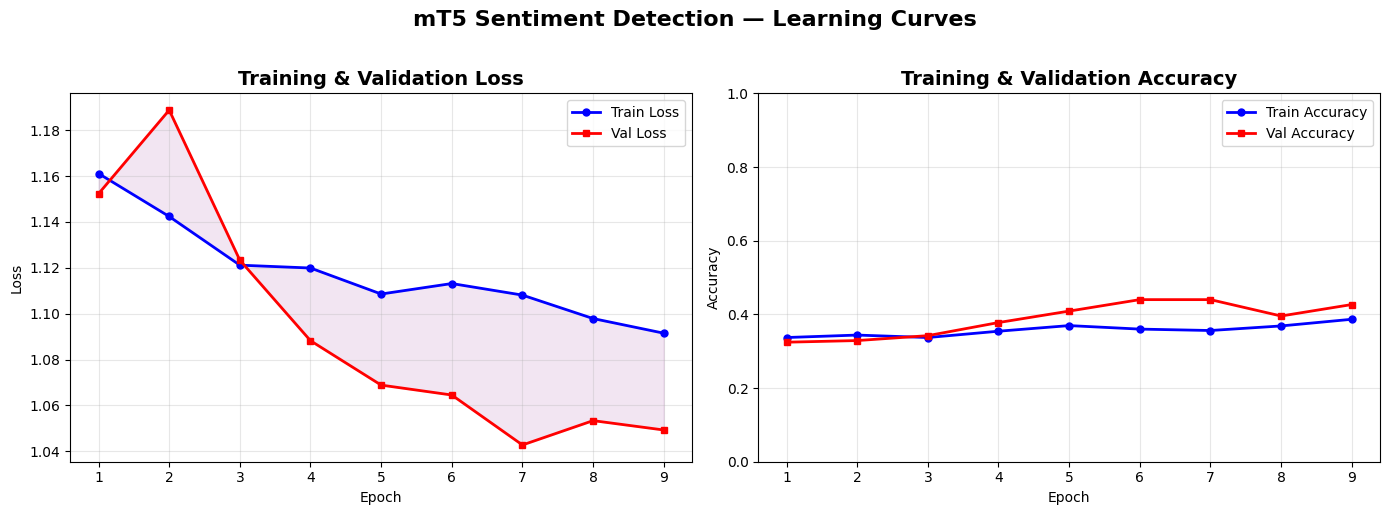

In [ ]:
epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Graph
axes[0].plot(x, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=5)
axes[0].plot(x, history['val_loss'],   'r-s', label='Val Loss',   linewidth=2, markersize=5)
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].fill_between(x, history['train_loss'], history['val_loss'], alpha=0.1, color='purple')

# Accuracy Graph
axes[1].plot(x, history['train_acc'], 'b-o', label='Train Accuracy', linewidth=2, markersize=5)
axes[1].plot(x, history['val_acc'],   'r-s', label='Val Accuracy',   linewidth=2, markersize=5)
axes[1].set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

plt.suptitle('mT5 Sentiment Detection — Learning Curves', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## CELL 12: Load Best Model & Test Evaluation


In [ ]:
print("\nLoading best model for test evaluation...")
model.load_state_dict(torch.load('best_mt5_sentiment.pt', map_location=device))

test_loss, test_acc, test_preds, test_labels = eval_epoch(model, test_loader, criterion, device)
test_f1 = f1_score(test_labels, test_preds, average='weighted')

print("\n" + "=" * 60)
print("              TEST SET RESULTS")
print("=" * 60)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  Weighted F1   : {test_f1:.4f}")
print("=" * 60)

label_names = ["Positive", "Neutral", "Negative"]
print("\nDetailed Classification Report:")
print(classification_report(test_labels, test_preds, target_names=label_names))


Loading best model for test evaluation...

              TEST SET RESULTS
  Test Loss     : 1.0365
  Test Accuracy : 0.4400 (44.00%)
  Weighted F1   : 0.3899

Detailed Classification Report:
              precision    recall  f1-score   support

    Positive       0.38      0.44      0.41        75
     Neutral       0.57      0.11      0.18        75
    Negative       0.46      0.77      0.58        75

    accuracy                           0.44       225
   macro avg       0.47      0.44      0.39       225
weighted avg       0.47      0.44      0.39       225



## CELL 13: Confusion Matrix


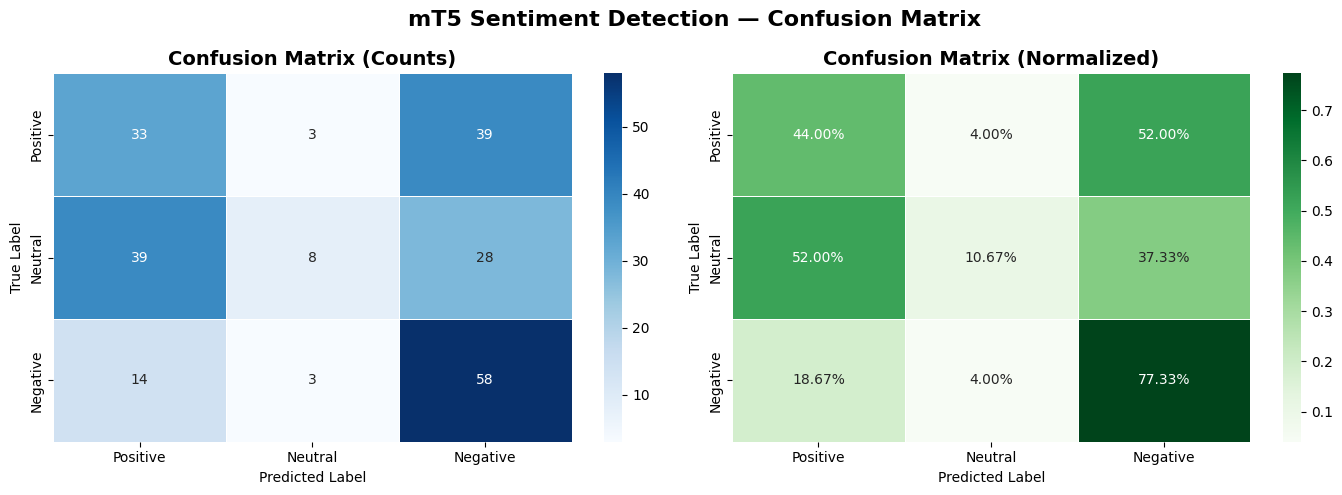

In [ ]:
cm = confusion_matrix(test_labels, test_preds)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=label_names, yticklabels=label_names,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.suptitle('mT5 Sentiment Detection — Confusion Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## CELL 14: Per-Class Metrics Bar Chart


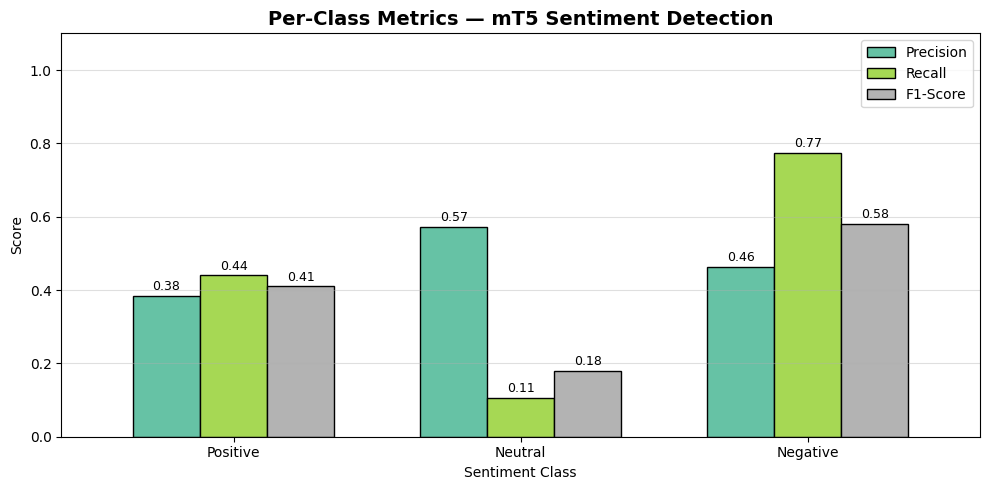

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    test_labels, test_preds, labels=[0, 1, 2]
)

metrics_df = pd.DataFrame({
    'Precision': precision,
    'Recall':    recall,
    'F1-Score':  f1
}, index=label_names)

ax = metrics_df.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black', width=0.7)
plt.title('Per-Class Metrics — mT5 Sentiment Detection', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Class')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.1)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.4)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2, fontsize=9)
plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## CELL 15: Predict New Texts (Inference)


In [ ]:
def predict_sentiment(texts, model, tokenizer, device, max_len=128):
    model.eval()
    if isinstance(texts, str):
        texts = [texts]
    encoding = tokenizer(
        texts,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits
        probs   = torch.softmax(logits, dim=1).cpu().numpy()
        preds   = torch.argmax(logits, dim=1).cpu().numpy()

    results = []
    for i, text in enumerate(texts):
        label_idx  = preds[i]
        sentiment  = id2label[label_idx]
        confidence = probs[i][label_idx]
        results.append({
            'text':            text[:80] + '...' if len(text) > 80 else text,
            'sentiment':       sentiment,
            'confidence':      f"{confidence:.2%}",
            'prob_positive':   f"{probs[i][0]:.2%}",
            'prob_neutral':    f"{probs[i][1]:.2%}",
            'prob_negative':   f"{probs[i][2]:.2%}",
        })
    return pd.DataFrame(results)


# Example predictions
sample_texts = [
    "Wishing everyone a very prosperous, healthy and happy new year!",
    "मला हे काम अजिबात आवडत नाही, खूप त्रास झाला",
    "आजचा दिवस सामान्य होता, काही विशेष नाही",
    "खूप छान कार्यक्रम झाला, सगळ्यांनी enjoy केला",
    "This government policy is very disappointing, very bad decision",
    "आज weather खूप छान आहे, mood fresh आहे!"
]

print("\n📊 Sample Predictions:")
pred_df = predict_sentiment(sample_texts, model, tokenizer, device)
print(pred_df.to_string(index=False))


📊 Sample Predictions:
                                                           text sentiment confidence prob_positive prob_neutral prob_negative
Wishing everyone a very prosperous, healthy and happy new year!  Negative     37.35%        27.23%       35.42%        37.35%
                    मला हे काम अजिबात आवडत नाही, खूप त्रास झाला  Positive     40.56%        40.56%       23.49%        35.94%
                        आजचा दिवस सामान्य होता, काही विशेष नाही  Negative     37.58%        36.51%       25.91%        37.58%
                   खूप छान कार्यक्रम झाला, सगळ्यांनी enjoy केला  Positive     38.59%        38.59%       28.76%        32.65%
This government policy is very disappointing, very bad decision   Neutral     35.34%        33.35%       35.34%        31.31%
                        आज weather खूप छान आहे, mood fresh आहे!  Positive     35.73%        35.73%       33.75%        30.52%


## CELL 16: Save Updated Dataset with Predictions


In [ ]:
# Add sentiment label column to original dataframe
df_final = df[['tweet', 'label', 'sentiment']].copy()
df_final.to_excel('dataset_with_sentiments.xlsx', index=False)
print("\n✅ Dataset with sentiment labels saved as 'dataset_with_sentiments.xlsx'")

# Save model + tokenizer
model.save_pretrained('mt5_sentiment_model')
tokenizer.save_pretrained('mt5_sentiment_model')
print("✅ Model and tokenizer saved to 'mt5_sentiment_model/'")

# Download all outputs
from google.colab import files
for fname in ['dataset_with_sentiments.xlsx', 'training_curves.png',
              'confusion_matrix.png', 'per_class_metrics.png', 'label_distribution.png']:
    files.download(fname)
    print(f"📥 Downloaded: {fname}")

print("\n🎉 Training complete!")
print(f"   Best Val Accuracy : {best_val_acc*100:.2f}%")
print(f"   Test Accuracy     : {test_acc*100:.2f}%")
print(f"   Weighted F1 Score : {test_f1:.4f}")


✅ Dataset with sentiment labels saved as 'dataset_with_sentiments.xlsx'


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model and tokenizer saved to 'mt5_sentiment_model/'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

📥 Downloaded: per_class_metrics.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Downloaded: label_distribution.png

🎉 Training complete!
   Best Val Accuracy : 44.00%
   Test Accuracy     : 44.00%
   Weighted F1 Score : 0.3899
